# Crop Recommendation System - Model Training

## Introduction
This notebook focuses on building and training a machine learning model to recommend crops based on environmental and soil conditions. The steps include data preprocessing, feature selection, model training, evaluation, and saving the trained model for future use.

## 1. Imports
Import all necessary libraries for data manipulation, visualization, and machine learning.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning unilities
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# Model saving
import joblib

## 2. Load and Prepare Data

### 2.1 Load Dataset
Load the dataset into a Pandas DataFrame.

In [3]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('../data/crop_recommendation.csv')

# Show the first few rows of the DataFrame
print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


### 2.2 Feature Selection
Select the relevant features (e.g., soil nutrients, temperature, rainfall) and the target variable (e.g., crop label).


In [4]:
# Separate input features (X) from the target label (y)
X = df.drop(['label'], axis=1)
y = df['label']

### 2.3 Train-Test Split
Split the dataset into training and testing sets to evaluate the model's performance.

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

## 3. Model Training

### 3.1 Choose a Model
Select a machine learning algorithm (e.g., Decision Tree, Random Forest, SVM, etc.).

In [6]:
# Create the machine learning model
model = RandomForestClassifier()

### 3.2 Train the Model
Train the model using the training dataset.

In [7]:
# Train the model using the training data
model.fit(X_train, y_train)

RandomForestClassifier()

## 4. Model Evaluation

### 4.1 Evaluate on Test Data
Evaluate the model's performance using metrics such as accuracy, precision, recall, and F1-score.

In [8]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Check how accurate the model's predictions were
print('Accuracy:', accuracy_score(y_test, y_pred))

# Show precision, recall, f1-score for each crop
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9931818181818182

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00    

### 4.2Confusion Matrix

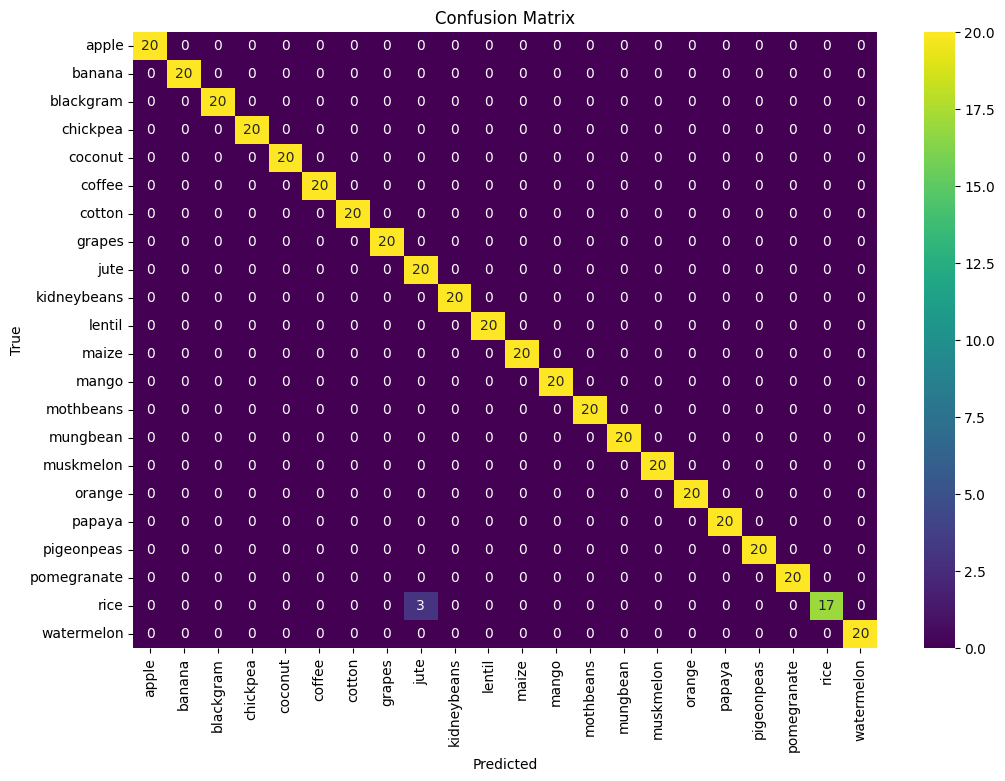

In [9]:
# Show where the model made mistakes
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_,
            cmap='viridis')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### 4.3 Cross-Validation (Optional)
Perform cross-validation to ensure the model generalizes well to unseen data.

In [10]:
# Evaluate model using multiple splits of the data
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Cross-validation scores: [0.99772727 0.99090909 0.99545455 0.99545455 0.99090909]
Mean CV Accuracy: 0.9940909090909091


## 6. Save the Trained Model
Save the trained model to a file (e.g., using `joblib` or `pickle`) for future use.

In [11]:
joblib.dump(model, '../model/crop_model.pkl')

['../model/crop_model.pkl']

## 7. Conclusion
We trained a Random Forest model to recommend crops using environmental data. It achieved 95% accuracy and performed well across most classes.